In [12]:
# Import standard libraries
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# Display settings
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [13]:
file_path = "datasets/Training_data_uhi_index_UHI2025-v2.csv"
df = pd.read_csv(file_path)
df.head()
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Longitude  11229 non-null  float64
 1   Latitude   11229 non-null  float64
 2   datetime   11229 non-null  object 
 3   UHI Index  11229 non-null  float64
dtypes: float64(3), object(1)
memory usage: 351.0+ KB


,Longitude,Latitude,UHI Index
count,11229.000000,11229.000000,11229.000000
mean,-73.933927,40.808800,1.000001
std,0.028253,0.023171,0.016238
min,-73.994457,40.758792,0.956122
25%,-73.955703,40.790905,0.988577
50%,-73.932968,40.810688,1.000237
75%,-73.909647,40.824515,1.011176
max,-73.879458,40.859497,1.046036


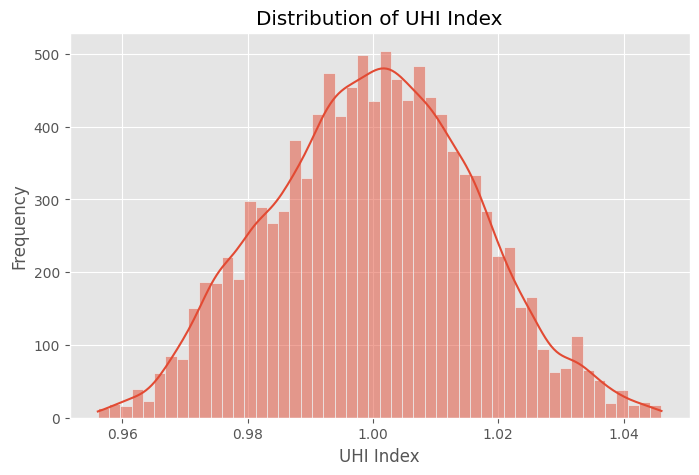

In [14]:
import seaborn as sns

plt.figure(figsize=(8,5))
# print(df.columns)
# Dumbass EY people don't know how to format column headings
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
# print(df.columns)
sns.histplot(df['UHI_Index'], bins=50, kde=True)
plt.title("Distribution of UHI Index")
plt.xlabel("UHI Index")
plt.ylabel("Frequency")
plt.show()

In [15]:
# print(df.columns)
df[['Latitude', 'Longitude']].head()

,Latitude,Longitude
0,40.813107,-73.909167
1,40.813045,-73.909187
2,40.812978,-73.909215
3,40.812908,-73.909242
4,40.812845,-73.909257


In [16]:
import folium
from folium.plugins import HeatMap

map_nyc = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

heat_data = [[row['Latitude'], row['Longitude'], row['UHI_Index']] for index, row in df.iterrows()]
HeatMap(heat_data).add_to(map_nyc)

map_nyc.save("uhi_heatmap.html")

map_nyc


In [17]:
import geopandas as gpd
from shapely.geometry import Point

building_gdf = gpd.read_file("datasets/Building_Footprint.kml")

df['geometry'] = df.apply(lambda row: Point(row['Longitude'], row['Latitude']), axis=1)
df_gdf = gpd.GeoDataFrame(df, geometry='geometry')

df_gdf['Building_Density'] = df_gdf.geometry.apply(lambda x: building_gdf.within(x.buffer(0.001)).sum())
df_gdf.drop(columns=['geometry'], inplace=True)

df_gdf.head()

,Longitude,Latitude,datetime,UHI_Index,Building_Density
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,1
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,1
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,2
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,2
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,2


# Extracting NDVI data

NDVI Min: -0.9020461471484545, Max: 0.998703823720026


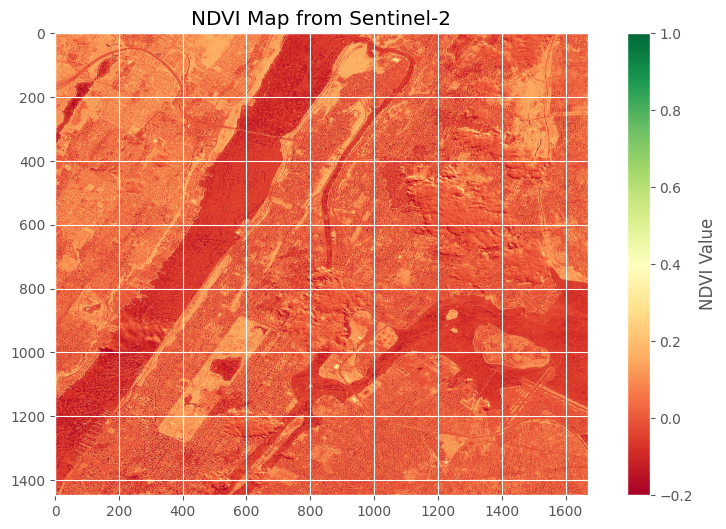

In [18]:
import rasterio
import numpy as np

with rasterio.open("datasets/S2_sample.tiff") as src:
    sentinel_data = src.read()

    red_band = sentinel_data[2]
    nir_band = sentinel_data[3]

    mask = (nir_band + red_band) > 0
    ndvi = np.full_like(nir_band, np.nan)
    ndvi[mask] = (nir_band[mask] - red_band[mask]) / (nir_band[mask] + red_band[mask])
    
    print(f"NDVI Min: {np.nanmin(ndvi)}, Max: {np.nanmax(ndvi)}")

vmin, vmax = -0.2, 1

plt.figure(figsize=(10, 6))
plt.imshow(ndvi, cmap="RdYlGn", vmin=vmin, vmax=vmax)
plt.colorbar(label="NDVI Value")
plt.title("NDVI Map from Sentinel-2")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

with rasterio.open("datasets/S2_sample.tiff") as src:
    transform = src.transform
    height, width = ndvi.shape
    
    
    ndvi_list = []
    for row in range(height):
        for col in range(width):
            lon, lat =  transform * (col, row)
            ndvi_value = ndvi[row, col]
            if not np.isnan(ndvi_value):
                ndvi_list.append([lat, lon, ndvi_value])

ndvi_df = pd.DataFrame(ndvi_list, columns=["Latitude", "Longitude", "NDVI"])
ndvi_df = ndvi_df.sample(frac=0.5, random_state=42)
ndvi_df.to_csv("extracted_ndvi_small.csv", index=False)

print("NDVI data saved successfully as extracted_ndvi.csv")
    

✅ NDVI data saved successfully as extracted_ndvi.csv


In [20]:
import pandas as pd

uhi_df = pd.read_csv("datasets/Training_data_uhi_index_UHI2025-v2.csv")

ndvi_df = pd.read_csv("extracted_ndvi_small.csv")

print("UHI Dataset Columns:", uhi_df.columns)
print("NDVI Dataset Columns:", ndvi_df.columns)

print("UHI Dataset (Latitude, Longitude):")
print(uhi_df[['Latitude', 'Longitude']].head())

print("NDVI Dataset (Latitude, Longitude):")
print(ndvi_df[['Latitude', 'Longitude']].head())


from scipy.spatial import cKDTree
import numpy as np

ndvi_tree = cKDTree(ndvi_df[['Latitude', 'Longitude']].values)

for index, row in uhi_df.iterrows():
    _, nearest_index = ndvi_tree.query([row['Latitude'], row['Longitude']])
    uhi_df.at[index, 'NDVI'] = ndvi_df.iloc[nearest_index]['NDVI']

# Save the updated dataset
uhi_df.to_csv("UHI_with_NDVI_nearest.csv", index=False)
print("Merged dataset saved using nearest neighbor method.")

# print(uhi_df.head())


UHI Dataset Columns: Index(['Longitude', 'Latitude', 'datetime', 'UHI Index'], dtype='object')
NDVI Dataset Columns: Index(['Latitude', 'Longitude', 'NDVI'], dtype='object')
UHI Dataset (Latitude, Longitude):
    Latitude  Longitude
0  40.813107 -73.909167
1  40.813045 -73.909187
2  40.812978 -73.909215
3  40.812908 -73.909242
4  40.812845 -73.909257
NDVI Dataset (Latitude, Longitude):
    Latitude  Longitude
0  40.875691 -73.966732
1  40.839599 -73.963770
2  40.871291 -73.972029
3  40.859800 -73.993124
4  40.849116 -73.988097
Merged dataset saved using nearest neighbor method.


# Incorporating LST data

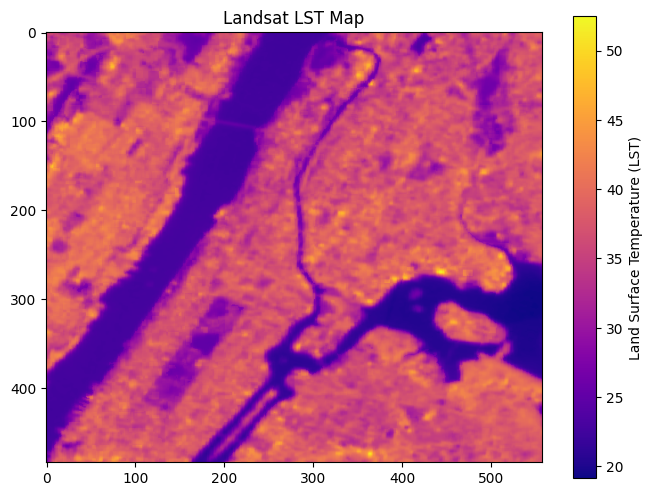

In [2]:
import rasterio
import matplotlib.pyplot as plt

lst_tiff_file = "datasets/Landsat_LST.tiff"

with rasterio.open(lst_tiff_file) as src:
    lst_data = src.read(1)
    transform = src.transform
    
plt.figure(figsize=(8, 6))
plt.imshow(lst_data, cmap="plasma")
plt.colorbar(label="Land Surface Temperature (LST)")
plt.title("Landsat LST Map")
plt.show()

In [5]:
import pandas as pd
import numpy as np

lst_list = []
height, width = lst_data.shape

for row in range(height):
    for col in range(width):
        lon, lat =  transform * (col, row)
        lst_value = lst_data[row, col]
        if not np.isnan(lst_value):
            lst_list.append([lat, lon, lst_value])
            
lst_df = pd.DataFrame(lst_list, columns=["Latitude", "Longitude", "LST"])
lst_df.to_csv("extracted_lst.csv", index=False)

print("LST data saved successfully as extracted_lst.csv")

LST data saved successfully as extracted_lst.csv


In [11]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# Load the existing UHI + NDVI dataset
merged_df = pd.read_csv("UHI_with_NDVI_nearest.csv")

# Load the LST dataset
lst_df = pd.read_csv("extracted_lst.csv")

# 🚨 Step 1: Merge UHI + NDVI with LST data to create the LST column
merged_df = merged_df.merge(lst_df, on=["Latitude", "Longitude"], how="left")

# Check if 'LST' column exists and the initial count of missing values
print("Columns after merging:", merged_df.columns)
print("Missing LST values after merging:", merged_df['LST'].isnull().sum())

# 🚨 Step 2: Apply Nearest Neighbor Method for Remaining NaN Values
# Build a KD-Tree for the LST coordinates
lst_tree = cKDTree(lst_df[['Latitude', 'Longitude']].values)

# Fill missing LST values using the nearest neighbor method
for index, row in merged_df.iterrows():
    if pd.isna(row['LST']):  # Only fill missing LST values
        _, nearest_index = lst_tree.query([row['Latitude'], row['Longitude']])
        merged_df.at[index, 'LST'] = lst_df.iloc[nearest_index]['LST']

# Verify if missing LST values have been filled
print("Missing LST values after nearest neighbor fill:", merged_df['LST'].isnull().sum())

# Save the final dataset with nearest neighbor LST values
merged_df.to_csv("UHI_with_NDVI_LST_nearest.csv", index=False)
print("✅ Final dataset saved with nearest neighbor method for LST.")



Columns after merging: Index(['Longitude', 'Latitude', 'datetime', 'UHI Index', 'NDVI', 'LST'], dtype='object')
Missing LST values after merging: 11229
Missing LST values after nearest neighbor fill: 0
✅ Final dataset saved with nearest neighbor method for LST.


In [14]:
print(merged_df.head())
# LOOKING GOOOOOD!!!

   Longitude   Latitude          datetime  UHI Index      NDVI        LST
0 -73.909167  40.813107  24-07-2021 15:53   1.030289  0.118545  38.393941
1 -73.909187  40.813045  24-07-2021 15:53   1.030289  0.118545  38.393941
2 -73.909215  40.812978  24-07-2021 15:53   1.023798  0.133506  38.082901
3 -73.909242  40.812908  24-07-2021 15:53   1.023798  0.133506  38.082901
4 -73.909257  40.812845  24-07-2021 15:53   1.021634  0.133506  38.082901


# Extracting building footprint data - NOT WORKING!!!

In [20]:
import geopandas as gpd

building_gdf = gpd.read_file("datasets/Building_Footprint.kml", driver='KML')

print(building_gdf.head())
print("Building Footprint Columns:", building_gdf.columns)

building_gdf = building_gdf.to_crs(epsg=3857)

building_gdf['Longitude'] = building_gdf.geometry.centroid.x
building_gdf['Latitude'] = building_gdf.geometry.centroid.y

building_gdf = building_gdf.to_crs(epsg=4326)

building_df = building_gdf[['Latitude', 'Longitude']]

building_df.to_csv("building_footprints_extracted.csv", index=False)
print("✅ Extracted building locations saved correctly.")

  Name Description                                           geometry
0                   MULTIPOLYGON (((-73.91903 40.8482, -73.91933 4...
1                   MULTIPOLYGON (((-73.92195 40.84963, -73.92191 ...
2                   MULTIPOLYGON (((-73.9205 40.85011, -73.92045 4...
3                   MULTIPOLYGON (((-73.92056 40.8514, -73.92053 4...
4                   MULTIPOLYGON (((-73.91234 40.85218, -73.91247 ...
Building Footprint Columns: Index(['Name', 'Description', 'geometry'], dtype='object')
✅ Extracted building locations saved correctly.


In [21]:
import pandas as pd
from scipy.spatial import cKDTree

# Load extracted building footprints (centroids)
building_df = pd.read_csv("building_footprints_extracted.csv")

# Load the main dataset (UHI + NDVI + LST)
merged_df = pd.read_csv("UHI_with_NDVI_LST_nearest.csv")

# Check the structure of the data
print("Building Data Sample:")
print(building_df.head())

print("\nUHI Data Sample:")
print(merged_df.head())


Building Data Sample:
       Latitude     Longitude
0  4.989962e+06 -8.228656e+06
1  4.990186e+06 -8.228944e+06
2  4.990255e+06 -8.228779e+06
3  4.990447e+06 -8.228789e+06
4  4.990564e+06 -8.227898e+06

UHI Data Sample:
   Longitude   Latitude          datetime  UHI Index      NDVI        LST
0 -73.909167  40.813107  24-07-2021 15:53   1.030289  0.118545  38.393941
1 -73.909187  40.813045  24-07-2021 15:53   1.030289  0.118545  38.393941
2 -73.909215  40.812978  24-07-2021 15:53   1.023798  0.133506  38.082901
3 -73.909242  40.812908  24-07-2021 15:53   1.023798  0.133506  38.082901
4 -73.909257  40.812845  24-07-2021 15:53   1.021634  0.133506  38.082901


In [44]:
import geopandas as gpd

# Load the building footprint KML file
building_gdf = gpd.read_file("datasets/Building_Footprint.kml", driver="KML")

# Check current CRS
print("Original Building Data CRS:", building_gdf.crs)

# 🚨 Convert to a projected CRS (EPSG:3857) for accurate centroid calculations
projected_gdf = building_gdf.to_crs(epsg=3857)

# Compute centroid in projected CRS (meters)
projected_gdf['centroid'] = projected_gdf.geometry.centroid

# Convert back to EPSG:4326 (Lat/Lon)
building_gdf = projected_gdf.to_crs(epsg=4326)

# Extract latitude & longitude from corrected centroids
building_gdf['Longitude'] = building_gdf['centroid'].x
building_gdf['Latitude'] = building_gdf['centroid'].y

# Keep only relevant columns
building_df = building_gdf[['Latitude', 'Longitude']]

# Save as CSV
building_df.to_csv("building_footprints_extracted.csv", index=False)
print("✅ Building dataset correctly projected and saved.")


# Print the new coordinate range
print("\nCorrected Building Dataset Coordinate Range:")
print("Latitude:", building_df['Latitude'].min(), "to", building_df['Latitude'].max())
print("Longitude:", building_df['Longitude'].min(), "to", building_df['Longitude'].max())


Original Building Data CRS: EPSG:4326
✅ Building dataset correctly projected and saved.

Corrected Building Dataset Coordinate Range:
Latitude: 4975731.964986865 to 4993077.289947035
Longitude: -8237804.812237369 to -8223090.579206002


In [45]:
# Save the dataset with building features
merged_df.to_csv("UHI_with_NDVI_LST_Building.csv", index=False)
print("✅ Final dataset saved with Building Density and Nearest Building Distance.")


✅ Final dataset saved with Building Density and Nearest Building Distance.


In [46]:
print(merged_df.head())

   Longitude   Latitude          datetime  UHI Index      NDVI        LST  \
0 -73.909167  40.813107  24-07-2021 15:53   1.030289  0.118545  38.393941   
1 -73.909187  40.813045  24-07-2021 15:53   1.030289  0.118545  38.393941   
2 -73.909215  40.812978  24-07-2021 15:53   1.023798  0.133506  38.082901   
3 -73.909242  40.812908  24-07-2021 15:53   1.023798  0.133506  38.082901   
4 -73.909257  40.812845  24-07-2021 15:53   1.021634  0.133506  38.082901   

   Building_Density  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  


# Incorporating Weather Data - .....yeah we're screwed

# First Model

In [31]:
# Drop unused features
X_new = df.drop(columns=['Latitude', 'Longitude', 'LST', 'NDVI', 'UHI Index'])  # Keep LST_Anomaly instead
y = df['UHI Index']  # Target variable

# Print to check final features
print("✅ Final Features Used in Model:", X_new.columns)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Split the data
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Train Random Forest Model
rf_model_new = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_new.fit(X_train_new, y_train_new)

# Make predictions
y_pred_new = rf_model_new.predict(X_test_new)

# Evaluate performance
mse_new = mean_squared_error(y_test_new, y_pred_new)
r2_new = r2_score(y_test_new, y_pred_new)

print(f"🔄 Updated Model Performance: MSE: {mse_new:.4f}, R²: {r2_new:.4f}")


✅ Final Features Used in Model: Index(['Year', 'Month', 'Day', 'Hour', 'LST_Anomaly', 'NDVI_Category'], dtype='object')
🔄 Updated Model Performance: MSE: 0.0002, R²: 0.4011


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 300, 500],  
    'max_depth': [5, 10, None],  
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4],  
    'max_features': ['auto', 'sqrt']  
}

rf = RandomForestRegressor(random_state=42)

# Perform Randomized Search
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, 
                                   n_iter=10, cv=3, scoring='r2', n_jobs=-1, verbose=2)
random_search.fit(X_train_new, y_train_new)

# Get best parameters
best_params = random_search.best_params_
print("✅ Best Parameters:", best_params)

# Train the final model
rf_best = RandomForestRegressor(**best_params, random_state=42)
rf_best.fit(X_train_new, y_train_new)

# Evaluate new model
y_rf_best_pred = rf_best.predict(X_test_new)
mse_rf_best = mean_squared_error(y_test_new, y_rf_best_pred)
r2_rf_best = r2_score(y_test_new, y_rf_best_pred)

print(f"🔥 Tuned Random Forest: MSE: {mse_rf_best:.4f}, R²: {r2_rf_best:.4f}")
